# Tutorial to use ImputeGAP

---
## 1. Introduction

### 1.1. Creating and visualizing an existent dataset

#### Create a timeseries object, load a series, normalize it

If I correctly understood the .txt series is a 2d representation of the dataset, each column is a channel, each row is a timestep, and then if you have multiple samples, you simply concatenate them as new rows. Then it is up to me to choose nbr_val to cut the samples.

In this case eeg-alcohol is a an individual sample, with 64 channels (features, time series) and 256 values (time length).

In [ ]:
from imputegap.recovery.manager import TimeSeries
from imputegap.tools import utils

# initialize the time series object
ts = TimeSeries()

# load and normalize the dataset from the library
ts.load_series(utils.search_path("eeg-alcohol"))
ts.normalize(normalizer="z_score")

# print and plot a subset of time series
ts.print(nbr_series=6, nbr_val=20)
ts.plot(input_data=ts.data, nbr_series=6, nbr_val=100, save_path="./imputegap_assets")

In [ ]:
# (T, V), T: time series, V: values
ts.data.shape

#### List of all the datasets available

In [ ]:
from imputegap.recovery.manager import TimeSeries
ts = TimeSeries()
print(f"ImputeGAP datasets : {ts.datasets}")

### 1.2. Contamination

In [ ]:
from imputegap.recovery.manager import TimeSeries
ts = TimeSeries()
print(f"Missingness patterns : {ts.patterns}")

### 1.3. Imputation

I had to install this on my ubuntu machine:
```bash
sudo apt-get install libopenblas0 libopenblas-dev
```

In [ ]:
from imputegap.recovery.manager import TimeSeries
ts = TimeSeries()
print(f"Imputation families : {ts.families}")
print(f"Imputation algorithms : {ts.algorithms}")

### 1.4. Others (still to check)

#### Parameter Tuning

In [ ]:
from imputegap.recovery.manager import TimeSeries
ts = TimeSeries()
print(f"AutoML Optimizers : {ts.optimizers}")

#### Benchmark

In [ ]:
from imputegap.recovery.benchmark import Benchmark

my_algorithms = ["SoftImpute", "MeanImpute"]

my_opt = ["default_params"]

my_datasets = ["eeg-alcohol"]

my_patterns = ["mcar"]

range = [0.05, 0.1, 0.2, 0.4, 0.6, 0.8]

my_metrics = ["*"]

# launch the evaluation
bench = Benchmark()
bench.eval(algorithms=my_algorithms, datasets=my_datasets, patterns=my_patterns, x_axis=range, metrics=my_metrics, optimizers=my_opt)

---
## 2. GPVAE Integration

For the integration, the datasets have been merge in individual .txt files for Physionet, and individual .npy files for both HMNIST and SPRITES. Train, val and test splits
have been merged in a individual file, and then in a config.yaml it is possible to specify the splits' lengths.

In npy files we have stored them as (T, V) np.arrays, T being the time series (channels) and V being the values, in this case having multiple independent samples, (T, S*V).

Example of how full train and test (no missingess) have been concatenated:

```python
import numpy as np
test = np.load('external/hmnist/hmnist_mnar.npz')
x_train_full = test['x_train_full']
x_test_full = test['x_test_full']

x_full = np.concatenate([x_train_full, x_test_full], axis=0)
np.save('external/hmnist/test.npy', x_full.transpose(2,0,1).reshape(784, -1))
```

Example of how miss_train and miss_test (with missing values, authors' contamination) have been concatenated:

```python
x_train_miss = test['x_train_miss']
m_train_miss = test['m_train_miss']
x_test_miss = test['x_test_miss']
m_test_miss = test['m_test_miss']

# 1s in the missing mask represent position of missing values (and they are 0.0)
np.unique(x_train_miss[m_train_miss==1])

# set missing values to NaN, indeed in the integration the gpvae expects to get incomp data with NaN, and then it 
# creates the mask in function of that and finally replace NaN with 0.0
x_train_miss_nan = x_train_miss.copy()
x_train_miss_nan[m_train_miss==1] = np.nan
x_test_miss_nan = x_test_miss.copy()
x_test_miss_nan[m_test_miss==1] = np.nan

# concatenate train and test (S_train + S_test, V, T)
x_miss_nan = np.concatenate(x_train_miss_nan, x_test_miss_nan)

# save the concatenate train and test miss (with nans)
np.save('external/hmnist/test.npy', x_miss_nan.transpose(2,0,1).reshape(784, -1))
```

---
Utils

In [4]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

def plot_training_results(path):
  with open(os.path.join(path, 'training_curve.tsv'), 'r') as infile:
      df = pd.read_csv(infile, sep='\t')

  # Filter to fetch only rows where also validation losses were computed
  no_nan = df.loc[np.invert(df['val_loss'].isna())]

  _, axes = plt.subplots(1, 3, figsize=(10, 4), layout='constrained')
  axes[0].plot(df.index, df['train_loss'], label='Train')
  axes[0].plot(no_nan.index, no_nan['val_loss'], label='Validation')
  axes[0].legend(loc='upper right')
  axes[0].set_title("Train and validation loss")
  axes[0].set_ylabel("Loss: NLL + beta*KL")
  axes[0].set_xlabel("Training steps")
  axes[1].plot(df.index, df['train_nll'], label='Train')
  axes[1].plot(no_nan.index, no_nan['val_nll'], label='Validation')
  axes[1].legend(loc='upper right')
  axes[1].set_title("Train and validation NLL")
  axes[1].set_ylabel("NLL")
  axes[1].set_xlabel("Training steps")
  axes[2].plot(df.index, df['train_kl'], label="Train")
  axes[2].plot(no_nan.index, no_nan['val_kl'], label="Validation")
  axes[2].legend(loc='upper right')
  axes[2].set_title("Train and validation KL")
  axes[2].set_ylabel("KL")
  axes[2].set_xlabel("Training steps")
  plt.show()


# for computer vision datasets (HMNIST and SPRITES) imputation visualization
def create_imputation_plot(image_shape, time_length, miss, imputed_no_gt, imputed, gt, sample_id, figsize=(15,5), cmap="gray"):
  miss[np.isnan(miss)] = 0.0
  fig, axes = plt.subplots(4, time_length, figsize=figsize, layout='constrained', sharey=True)

  for j in range(time_length):
    axes[0, j].imshow(np.clip(miss[sample_id,j].reshape(*image_shape), 0, 1), cmap=cmap)
    axes[1, j].imshow(np.clip(imputed_no_gt[sample_id,j].reshape(*image_shape), 0, 1), cmap=cmap)
    axes[2, j].imshow(np.clip(imputed[sample_id,j].reshape(*image_shape), 0, 1), cmap=cmap)
    axes[3, j].imshow(np.clip(gt[sample_id,j].reshape(*image_shape), 0, 1), cmap=cmap)
    axes[0,j].axis('off')
    axes[1,j].axis('off')
    axes[2,j].axis('off')
    axes[3,j].axis('off')
  axes[0,0].set_ylabel("Miss")
  fig.suptitle("Miss -> Imputed (no GT) -> Imputed | GT")
  plt.show()

### 2.1 Train the GPVAE model with missingess patterns provided by the author

#### 2.1.1. Physionet

In [ ]:
from imputegap.recovery.manager import TimeSeries
from imputegap.algorithms.gp_vae import gp_vae

# initialize the time series object
ts = TimeSeries()

# load and normalize the dataset
ts.load_series("./external/datasets/physionet/merged/x_miss_nan.txt")
# ts.normalize(normalizer="z_score")

ts_m_imputed = gp_vae(ts.data, 
                      "imputegap/wrapper/AlgoPython/GPVAE/config_gpvae_physionet.yaml", 
                      verbose=False)

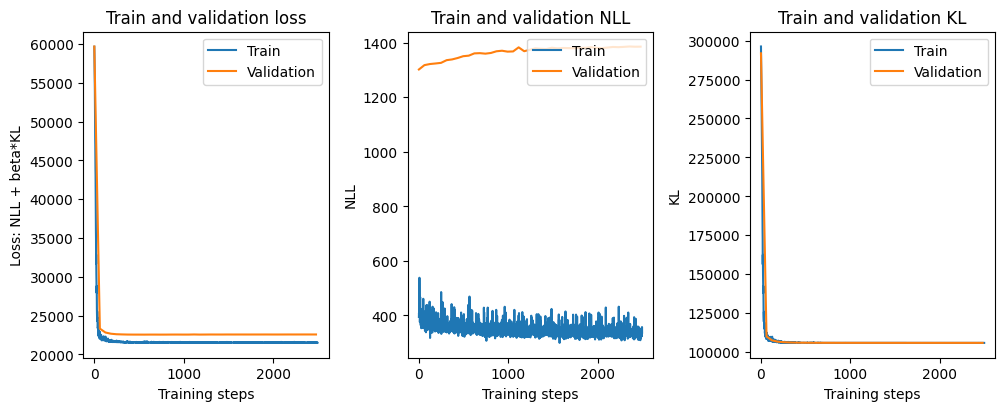

In [7]:
# plot training results
# exp_folder = 'imputegap_assets/models/20251205_151509'
exp_folder = '/home/kaeslin/Downloads/physionet_trained'
plot_training_results(exp_folder)

In [ ]:
with open('/home/kaeslin/Downloads/content/training_curve.tsv', 'r') as infile:
      df = pd.read_csv(infile, sep='\t')

Reload model and impute one sample

In [ ]:
from imputegap.recovery.manager import TimeSeries
from imputegap.algorithms.gp_vae import gp_vae

# initialize the time series object
ts = TimeSeries()

# 28th sample (index 27)
sample_idx = 27
seq_length = 48
nbr_features = 35
flatten_idx = sample_idx*seq_length

# model folder
# model_folder = 'imputegap_assets/models/20251205_151509'
model_folder = 'external/models/251123_reproduce_physionet'

# import single sample
ts.load_series('./external/datasets/physionet/merged/x_full.txt')
# load and normalize the dataset
# ts.normalize(normalizer="z_score")

# Add missingness to the data, ts has shape (T, V)
ts_m = ts.Contamination.mcar(ts.data[:,flatten_idx:flatten_idx+seq_length], 
                             rate_dataset=0.4, 
                             rate_series=0.2, 
                             block_size=7, 
                             seed=True)

ts.plot(ts.data[:,flatten_idx:flatten_idx+seq_length], ts_m, subplot=True)

ts_m_imputed = gp_vae(ts_m, 
                      "imputegap/wrapper/AlgoPython/GPVAE/config_gpvae_physionet.yaml", 
                      model_folder, 
                      verbose=True)

ts.plot(input_data=ts.data[:,flatten_idx:flatten_idx+seq_length], incomp_data=ts_m, recov_data=ts_m_imputed, nbr_series=35, subplot=True, algorithm="GP-VAE", save_path="./imputegap_assets/imputation")

---
#### 2.1.2. HMNIST

In [ ]:
from imputegap.recovery.manager import TimeSeries
from imputegap.algorithms.gp_vae import gp_vae
import numpy as np

# initialize the time series object
ts = TimeSeries()

# load and normalize the dataset
hmnist_nan = np.load("./external/datasets/hmnist/x_miss_nan.npy")
ts.import_matrix(hmnist_nan)
# ts.normalize(normalizer="z_score")

ts_m_imputed = gp_vae(ts.data, 
                      "imputegap/wrapper/AlgoPython/GPVAE/config_gpvae_hmnist.yaml", 
                      batch_size=64, epoch=2, verbose=True)

In [ ]:
import pandas as pd
with open('external/models/251113_reproduce_hmnist/training_curve.tsv', 'r') as infile:
      df = pd.read_csv(infile, sep='\t')
df

,8084.8975,7992.1865,7813.4863,7244.5986,6165.119,4434.651,3226.556,3456.1138,3543.084,3021.7778,...,1305.7144,1289.512,1293.0194,1306.2605,1311.2039,1328.6156,1303.627,1308.2183,1300.4775,1294.5842
0,8007.662,1438.7996,1369.7809,1339.1965,1352.0308,1324.333,1334.893,1329.326,1337.8589,1330.5177,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


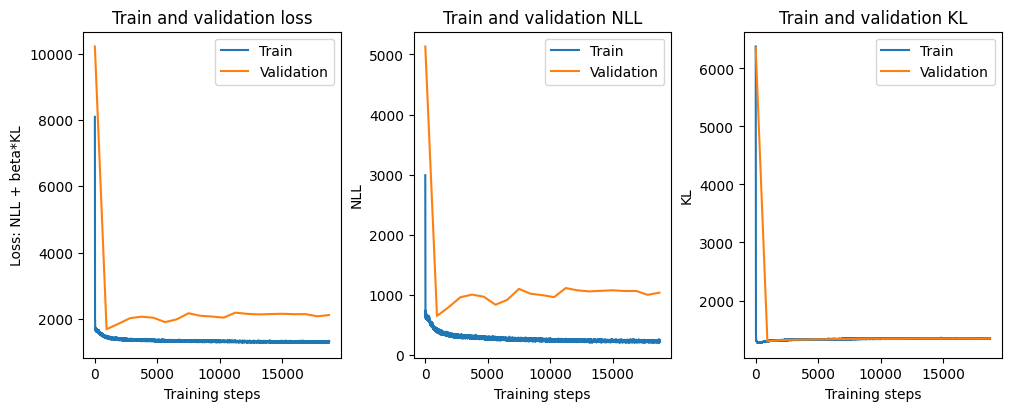

In [6]:
# plot training results
# exp_folder = 'imputegap_assets/models/20251205_152733'
exp_folder = '/home/kaeslin/Downloads/hmnist_trained'
plot_training_results(exp_folder)

Reload model and impute one sample

In [ ]:
from imputegap.recovery.manager import TimeSeries
from imputegap.algorithms.gp_vae import gp_vae
import numpy as np

# initialize the time series object
ts = TimeSeries()

# 28th sample (index 27)
sample_idx = 27
seq_length = 10
nbr_features = 784
flatten_idx = sample_idx*seq_length

# model folder
# model_folder = 'imputegap_assets/models/20251205_152733'
model_folder = 'external/models/251113_reproduce_hmnist'

hmnist_full = np.load("./external/datasets/hmnist/x_full.npy")

# load and normalize the dataset
ts.import_matrix(hmnist_full)
# ts.normalize(normalizer="z_score")

# Add missingness to the data, ts has shape (T, V)
ts_m = ts.Contamination.mcar(ts.data[:,flatten_idx:flatten_idx+seq_length], 
                             rate_dataset=1.0, 
                             rate_series=0.8, 
                             block_size=7, 
                             seed=True)

ts_m_imputed = gp_vae(ts_m, 
                      "imputegap/wrapper/AlgoPython/GPVAE/config_gpvae_hmnist.yaml", 
                      model_folder, 
                      verbose=True)

In [ ]:
create_imputation_plot((28,28,1), 
                       10, 
                       np.expand_dims(ts_m.T, axis=0),
                       np.expand_dims(ts_m_imputed.T, axis=0),
                       np.expand_dims(ts_m_imputed.T, axis=0),
                       np.expand_dims(ts.data[:,flatten_idx:flatten_idx+seq_length].T, axis=0),
                       0, cmap="gray")

---
#### 2.1.3. Sprites

In [ ]:
from imputegap.recovery.manager import TimeSeries
from imputegap.algorithms.gp_vae import gp_vae
import numpy as np

# initialize the time series object
ts = TimeSeries()

# load and normalize the dataset
# to avoid memory overflow I slice the dataset and change splits in the config
# accordingly
sprites_nan = np.load("./external/datasets/sprites/x_miss_nan.npy")[:,:10_000]
ts.import_matrix(sprites_nan)
# ts.normalize(normalizer="z_score")

ts_m_imputed = gp_vae(ts.data, 
                      "imputegap/wrapper/AlgoPython/GPVAE/config_gpvae_sprites.yaml", 
                      batch_size=64, epoch=2, verbose=True)

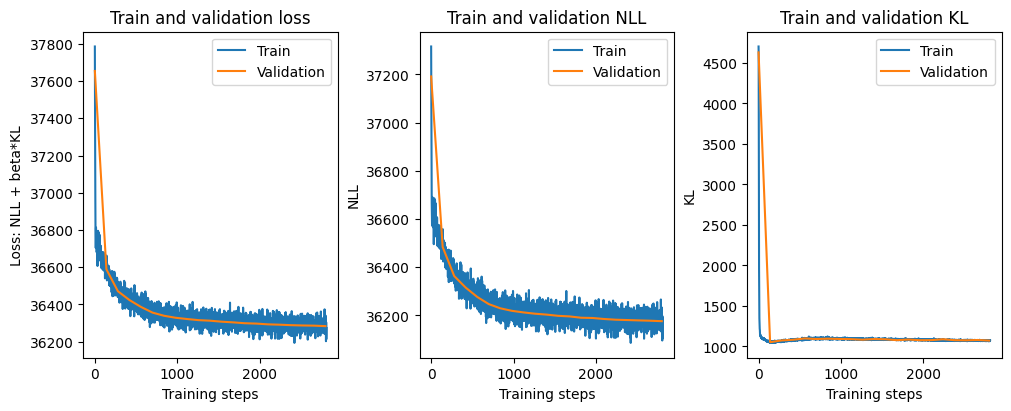

In [5]:
# plot training results
# exp_folder = 'imputegap_assets/models/20251205_204940'
exp_folder = '/home/kaeslin/Downloads/sprites_trained'
plot_training_results(exp_folder)

In [2]:
import pandas as pd
with open('external/models/251114_reproduce_sprites/training_curve.tsv', 'r') as infile:
      df = pd.read_csv(infile, sep='\t')
df

,37685.293,37684.496,37468.477,37248.676,37847.367,36947.773,36970.086,37003.33,36963.96,36812.43,...,36349.68,36257.305,36260.086,36246.117,36390.83,36259.69,36279.81,36309.72,36284.54,36302.094
0,37786.67,36600.426,36493.406,36503.918,36348.89,36312.715,36349.06,36276.836,36302.86,36260.65,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Reload a model and impute

With sprites the issue is that the reconstruction works well if the contamination is done in a way that we either remove all three channels for a pixel, or keep them all.

In [ ]:
from imputegap.recovery.manager import TimeSeries
from imputegap.algorithms.gp_vae import gp_vae
import numpy as np

# initialize the time series object
ts = TimeSeries()

# 28th sample (index 27)
sample_idx = 27
seq_length = 8
nbr_features = 12288
flatten_idx = sample_idx*seq_length

# model folder
# model_folder = 'imputegap_assets/models/20251205_204940'
model_folder = 'external/models/251114_reproduce_sprites'

sprites_full = np.load("./external/datasets/sprites/x_full.npy")[:,:10000]

# load and normalize the dataset
ts.import_matrix(sprites_full)
# ts.normalize(normalizer="z_score")

# Add missingness to the data, ts has shape (T, V)
ts_m = ts.Contamination.mcar(ts.data[:,flatten_idx:flatten_idx+seq_length], 
                             rate_dataset=1.0, 
                             rate_series=0.8, 
                             block_size=3, 
                             seed=True)

ts_m_imputed = gp_vae(ts_m, 
                      "imputegap/wrapper/AlgoPython/GPVAE/config_gpvae_sprites.yaml", 
                      model_folder, 
                      verbose=True)

In [ ]:
create_imputation_plot((64,64,3),
                       8, 
                       np.expand_dims(ts_m.T, axis=0),
                       np.expand_dims(ts_m_imputed.T, axis=0),
                       np.expand_dims(ts_m_imputed.T, axis=0),
                       np.expand_dims(ts.data[:,flatten_idx:flatten_idx+seq_length].T, axis=0),
                       0, cmap=None)

## 3. New Experiment

Keeping the same trained model on MNAR (reproducibility experiment). MNAR: Missing Not At Random, white pixels are two times more likely to be missing. 

### 3.1. Compute statistics on the missing data given by the authors

In [ ]:
# mask given as (S, V, T)
def compute_mask_stastics(mask): 
  s, v, t = mask.shape
  miss_per_img = np.sum(mask, axis=2).reshape(-1) / t
  img_avg, img_std = np.mean(miss_per_img), np.std(miss_per_img)

  miss_per_sample = np.sum(mask, axis=(2,1)) / (v*t)
  sample_avg, sample_std = np.mean(miss_per_sample), np.std(miss_per_sample)

  tot_miss_ratio = np.sum(mask) / (s*v*t)

  mask = mask.transpose(0,2,1)
  miss_per_series = np.sum(mask, axis=2)
  series_avg = np.mean(miss_per_series, axis=1)
  series_std = np.std(miss_per_series, axis=1)

  return ((img_avg, img_std), (sample_avg, sample_std), tot_miss_ratio, (np.mean(series_avg), np.mean(series_std)))

In [ ]:
import numpy as np

hmnist_miss = np.load('external/datasets/hmnist/x_miss_nan.npy')
hmnist_miss = hmnist_miss.reshape(784, 70_000, 10).transpose(1,2,0)
mask = np.isnan(hmnist_miss)
hmnist_miss[mask] = 0.0

### 3.2. Authors' HMNIST MNAR

In [ ]:
from imputegap.recovery.manager import TimeSeries
from imputegap.algorithms.gp_vae import gp_vae
import numpy as np

# initialize the time series object
ts = TimeSeries()

seq_length = 10
nbr_features = 784

# model folder
# model_folder = 'imputegap_assets/models/20251205_152733'
model_folder = 'external/models/251113_reproduce_hmnist'
validation_idx = 600_000
nr_samples_test = 122
sample_idx = 61

hmnist_miss_val = np.load("./external/datasets/hmnist/x_miss_nan.npy")[:,validation_idx:validation_idx+seq_length*nr_samples_test]
hmnist_full_val_gt = np.load("./external/datasets/hmnist/x_full.npy")[:,validation_idx:validation_idx+seq_length*nr_samples_test]

# load and normalize the dataset
ts.import_matrix(hmnist_miss_val)
# ts.normalize(normalizer="z_score")
ground_truth = hmnist_full_val_gt.T.reshape(-1,seq_length,nbr_features)

try:
  ts_m_imputed, ts_m_imputed_no_gt, results = gp_vae(ts.data, 
                        "imputegap/wrapper/AlgoPython/GPVAE/config_gpvae_hmnist.yaml", 
                        model_folder,
                        ground_truth=ground_truth,
                        return_no_gt_imputation=True,
                        verbose=False)

  print(results)
  print(compute_mask_stastics(np.isnan(hmnist_miss_val.T.reshape(-1, 10, 784))))
  
  create_imputation_plot((28,28,1),
                       10, 
                       ts.data.T.reshape(-1, seq_length, nbr_features),
                       ts_m_imputed_no_gt.T.reshape(-1, seq_length, nbr_features),
                       ts_m_imputed.T.reshape(-1, seq_length, nbr_features),
                       ground_truth,
                       sample_idx)  
finally:
  ts=None
  hmnist_miss_val = None
  hmnist_full_val_gt = None

### 3.3. Custom Contaminations

To contaminate effectively I need more data, seq_length of 10 is too small, already with the offset the start of the sequence is not contaminated. Solution, contaminate a larger set of data, and then select to visualize the imputation, in this way however, the nll and mse are not probably representative of the contamination. I think I could then save the contamination of the specific sample, and evaluate it individually.

Scattered

In [ ]:
from imputegap.recovery.manager import TimeSeries
from imputegap.algorithms.gp_vae import gp_vae
import numpy as np

# initialize the time series object
ts = TimeSeries()

seq_length = 10
nbr_features = 784

# model folder
# model_folder = 'imputegap_assets/models/20251205_152733'
model_folder = 'external/models/251113_reproduce_hmnist'

validation_idx = 600_000
nr_samples_test = 122
sample_idx = 61

rate_dataset = 1.0
rate_series = 0.4
offset=0.1

hmnist_full_val_gt = np.load("./external/datasets/hmnist/x_full.npy")[:,validation_idx:validation_idx+seq_length*nr_samples_test]

# load and normalize the dataset
ts.import_matrix(hmnist_full_val_gt)
# ts.normalize(normalizer="z_score")

print(ts.data.shape)
# Add missingness to the data, ts has shape (T, V)
ts_m = ts.Contamination.scattered(ts.data,rate_dataset=rate_dataset,
                                  rate_series=rate_series, 
                                  offset=offset)

ground_truth = hmnist_full_val_gt.T.reshape(-1,seq_length,nbr_features)

try:
  ts_m_imputed, ts_m_imputed_no_gt, results = gp_vae(ts_m[:, sample_idx*seq_length:sample_idx*seq_length+seq_length], 
                      "imputegap/wrapper/AlgoPython/GPVAE/config_gpvae_hmnist.yaml", 
                      model_folder,
                      ground_truth=ground_truth[sample_idx:sample_idx+1],
                      return_no_gt_imputation=True,
                      verbose=False)

  print(results)
  print(compute_mask_stastics(np.isnan(ts_m[:, sample_idx*seq_length:sample_idx*seq_length+seq_length].T.reshape(-1, 10, 784))))

  create_imputation_plot((28,28,1),
                        10, 
                        ts_m[:, sample_idx*seq_length:sample_idx*seq_length+seq_length].T.reshape(-1, seq_length, nbr_features),
                        ts_m_imputed_no_gt.T.reshape(-1, seq_length, nbr_features),
                        ts_m_imputed.T.reshape(-1, seq_length, nbr_features),
                        ground_truth[sample_idx:sample_idx+1],
                        0)
  
finally:
  ts=None
  hmnist_miss_val = None
  hmnist_full_val_gt = None

MCAR

In [ ]:
from imputegap.recovery.manager import TimeSeries
from imputegap.algorithms.gp_vae import gp_vae
import numpy as np

# initialize the time series object
ts = TimeSeries()

seq_length = 10
nbr_features = 784

# model folder
# model_folder = 'imputegap_assets/models/20251205_152733'
model_folder = 'external/models/251113_reproduce_hmnist'

validation_idx = 600_000
sample_idx = 61
nr_samples_test = 122

# contamination parameters
rate_dataset = 1.0
rate_series = 0.8
block_size = 3

hmnist_full_val_gt = np.load("./external/datasets/hmnist/x_full.npy")[:,validation_idx:validation_idx+seq_length*nr_samples_test]

# load and normalize the dataset
ts.import_matrix(hmnist_full_val_gt)
# ts.normalize(normalizer="z_score")

print(ts.data.shape)
# Add missingness to the data, ts has shape (T, V)
ts_m = ts.Contamination.mcar(ts.data,
                             rate_dataset=rate_dataset, 
                             rate_series=rate_series, block_size=block_size)

ground_truth = hmnist_full_val_gt.T.reshape(-1,seq_length,nbr_features)

try:
  ts_m_imputed, ts_m_imputed_no_gt, results = gp_vae(ts_m[:, sample_idx*seq_length:sample_idx*seq_length+seq_length], 
                      "imputegap/wrapper/AlgoPython/GPVAE/config_gpvae_hmnist.yaml", 
                      model_folder,
                      ground_truth=ground_truth[sample_idx:sample_idx+1],
                      return_no_gt_imputation=True,
                      verbose=False)

  print(results)
  print(compute_mask_stastics(np.isnan(ts_m[:, sample_idx*seq_length:sample_idx*seq_length+seq_length].T.reshape(-1, 10, 784))))

  create_imputation_plot((28,28,1),
                        10, 
                        ts_m[:, sample_idx*seq_length:sample_idx*seq_length+seq_length].T.reshape(-1, seq_length, nbr_features),
                        ts_m_imputed_no_gt.T.reshape(-1, seq_length, nbr_features),
                        ts_m_imputed.T.reshape(-1, seq_length, nbr_features),
                        ground_truth[sample_idx:sample_idx+1],
                        0)
  
finally:
  ts=None
  hmnist_miss_val = None
  hmnist_full_val_gt = None